In [1]:
import numpy
import matplotlib.pyplot as plt
import torch

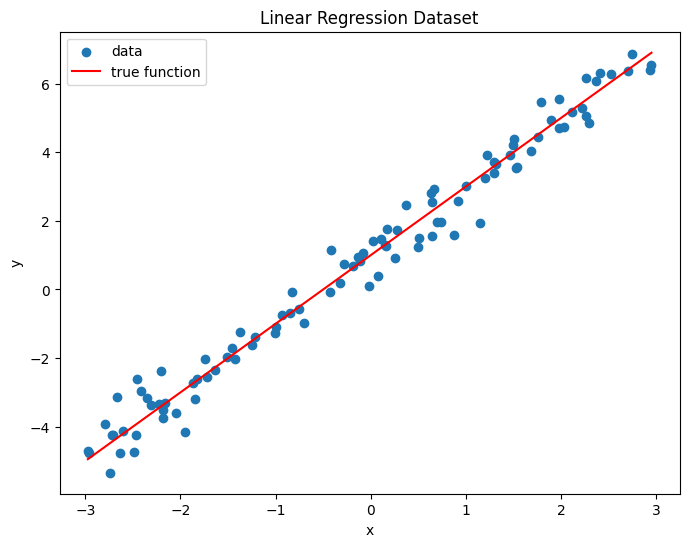

In [2]:
# データの準備
# linear regression: y = 2x + 1 + noise
linear = lambda x: 2 * x + 1
x = numpy.random.rand(100, 1) * 6 - 3
noise = numpy.random.randn(100, 1) * 0.5
y = linear(x) + noise

# plot 
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='data')
_x = numpy.linspace(numpy.min(x), numpy.max(x), 100).reshape(-1, 1)
plt.plot(_x, linear(_x), color='red', label='true function')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Dataset')
plt.legend()
plt.show()

In [3]:
# define model
class Model(torch.nn.Module):
    """ 最も単純な線形回帰モデル

    Linear レイヤーは

        y = x * w + b

    のような線形変換を行うレイヤーで、入力 x に対して重みパラメータ w とバイアスパラメータ b を学習する
    """
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)

    def forward(self, x):
        # return self.linear(x)
        out = self.linear(x)  # (1,1)　行列かけ、バイアス足す
        return out

In [6]:
# define training loop
def train(
        model, 
        x_train, 
        y_train, 
        num_epochs = 1000, 
        learning_rate = 0.01, 
        plot_interval: int | float | None = None
        ):
    """ モデルのトレーニング（パラメータ最適化）を行う関数

    Args:
        model: トレーニングするPyTorchモデル
        x_train: 入力トレーニングデータ（特徴量）
        y_train: 目標トレーニングデータ（ラベル）
        num_epochs: モデルをトレーニングするエポック数
        learning_rate: オプティマイザの学習率
        plot_interval: 指定された場合、トレーニング中に回帰線をプロットする
            - int: num_epochsのこの数値ごとにプロット
            - float: num_epochsのこの割合ごとにプロット
            - None: プロットなし
    """
    criterion = torch.nn.MSELoss()
    # optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    loss_history = []

    if plot_interval is not None:
        # plotの準備
        plt.figure(figsize=(8, 6))
        plt.scatter(x_train.numpy(), y_train.numpy(), label='data')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Linear Regression Training')
        cmap = plt.get_cmap('viridis')

    for epoch in range(num_epochs):
        # training前の準備：モデルを訓練モードに設定し、勾配を初期化する
        model.train()
        optimizer.zero_grad()
        # training 開始
        outputs = model(x_train) # y_pred = f(x_train) 
        # loss = criterion(outputs, y_train)  # chi-equare: loss = (y_pred - y_train)^2
        # 自前実装
        loss = torch.mean((outputs - y_train) ** 2)
        loss.backward()  # 勾配計算
        loss_history.append(loss.detach().cpu().item())
        optimizer.step()

        # plot_intervalで指定された場合、回帰線をプロット
        if plot_interval is not None:
            # plot_intervalに応じて、トレーニングの進行状況を表示
            actual_interval = plot_interval if isinstance(plot_interval, int) else int(num_epochs * plot_interval)
            if (epoch + 1) % actual_interval == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_history[-1]:.4f}')
                # plot regression line
                with torch.no_grad():
                    predicted = model(x_train).detach().numpy()
                # plot用にデータをソート
                sorted_indices = x_train.numpy().argsort(axis=0).flatten()
                plt.plot(x_train.numpy()[sorted_indices], predicted[sorted_indices], label=f'Epoch {epoch+1}', color=cmap(epoch / num_epochs))
    if plot_interval is not None:
        plt.legend(loc='upper left')
    return model, loss_history, plt.gcf()



Epoch [1000/10000], Loss: 3.8971
Epoch [2000/10000], Loss: 0.9420
Epoch [3000/10000], Loss: 0.3027
Epoch [4000/10000], Loss: 0.2521
Epoch [5000/10000], Loss: 0.2514
Epoch [6000/10000], Loss: 0.2514
Epoch [7000/10000], Loss: 0.2514
Epoch [8000/10000], Loss: 0.2514
Epoch [9000/10000], Loss: 0.2514
Epoch [10000/10000], Loss: 0.2514


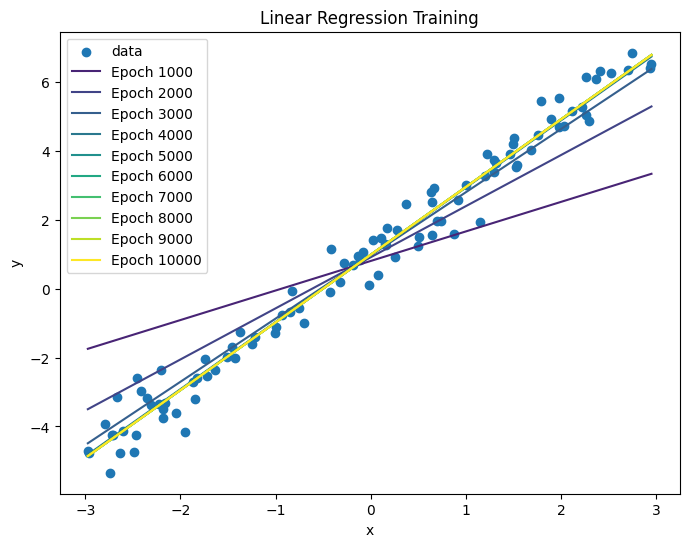

In [7]:
# training start
model = Model()
x_train = torch.from_numpy(x).float()
y_train = torch.from_numpy(y).float()
train(model, x_train, y_train, num_epochs=10000, learning_rate=0.001, plot_interval=0.1)
plt.legend()
plt.show()